In [1]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_bspline

In [2]:
k_steps = 5
k_buffer = 10
n_time_steps = 100
n_nodes = 200
density = 0.2

Y, X, probas_true = simulate_network_bspline(
        n_nodes=n_nodes, n_time_steps=n_time_steps,
        density=density, df=5, k_buffer=k_buffer,
        k_steps=k_steps, random_state=123)

In [3]:
rdpg_rw2 = DynamicRDPG(n_features=2, rw_order=2, random_state=42)
rdpg_rw2.sample(Y[:-k_steps], n_burnin=2500, n_samples=2500)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [45:51<00:00,  1.82it/s]


In [4]:
rdpg_rw1 = DynamicRDPG(n_features=2, rw_order=1, random_state=42)
rdpg_rw1.sample(Y[:-k_steps], n_burnin=2500, n_samples=2500)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [44:09<00:00,  1.89it/s]


In [5]:
from graspologic.embed import AdjacencySpectralEmbed as ASE
import scipy.sparse as sp
from scipy.linalg import orthogonal_procrustes

X_ase = []
proba_ase = []
for t in range(len(Y[:-k_steps])):
    X_ase.append(ASE(n_components=2).fit_transform(sp.csr_array(Y[t])))
    proba_ase.append(X_ase[t] @ X_ase[t].T)
X_ase = np.stack(X_ase)
proba_ase = np.clip(np.stack(proba_ase), 0, 1)

for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_ase[t], X[t])
    X_ase[t] = X_ase[t] @ R

/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


In [6]:
from graspologic.embed import OmnibusEmbed as OMNI

X_omni = OMNI(n_components=2).fit_transform(Y[:-k_steps])
proba_omni = []
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_omni[t], X[t])
    X_omni[t] = X_omni[t] @ R
    proba_omni.append(X_omni[t] @ X_omni[t].T)
proba_omni = np.clip(np.stack(proba_omni), 0, 1)

In [7]:
import scipy.sparse as sp

n_nodes, _ = Y[0].shape
A = sp.csr_array(np.hstack([Yt for Yt in Y[:-k_steps]]))
u, s, vh= sp.linalg.svds(A, k=2)
s_sqrt = np.sqrt(s)[::-1]
X_uase = (vh.T[:, ::-1] * s_sqrt).reshape(len(Y[:-k_steps]), n_nodes, 2)
Y_uase = u[:, ::-1] * s_sqrt

proba_uase = []
for t in range(len(Y)-k_steps):
    proba_uase.append(np.clip(Y_uase @ X_uase[t].T, 0, 1))
proba_uase = np.clip(np.stack(proba_uase), 0, 1)

In [8]:
from graspologic.embed import MultipleASE as MASE
import scipy

mase = MASE(n_components=2).fit(Y[:-k_steps])
X_mase_fit = mase.latent_left_

proba_mase = []
for t in range(len(Y)-k_steps):
    proba_mase.append(np.clip(mase.latent_left_ @ mase.scores_[t] @ mase.latent_left_.T, 0, 1))
    
proba_mase = np.clip(np.stack(proba_mase), 0, 1)

In [9]:
probas_pred_rw2 = rdpg_rw2.predict(n_samples=500)
probas_forecast_rw2 = rdpg_rw2.forecast(k_steps=k_steps, n_samples=500, return_subdiag=False)

In [10]:
probas_pred_rw1 = rdpg_rw1.predict(n_samples=500)
probas_forecast_rw1 = rdpg_rw1.forecast(k_steps=k_steps, n_samples=500, return_subdiag=False)

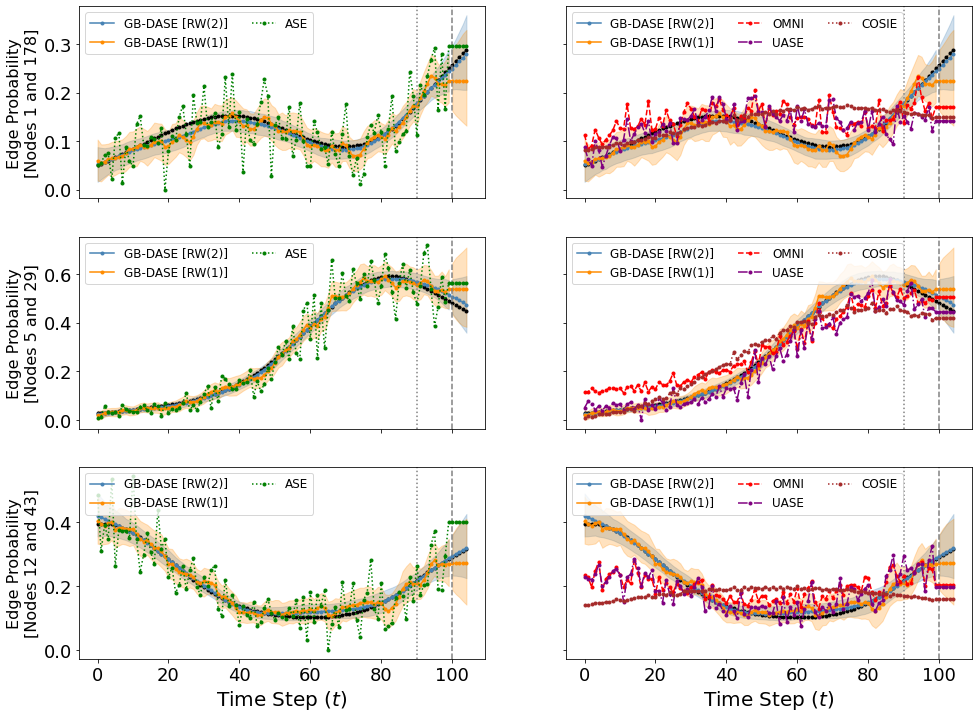

In [13]:
n_time_steps, n_nodes, _ = rdpg_rw2.X_.shape

fig, ax = plt.subplots(figsize=(16, 12), nrows=3, ncols=2, sharey='row', sharex=True)

for k, (i, j) in enumerate([(1, 178), (5, 29), (12, 43)]):
    # Truth
    ax[k, 0].plot(probas_true[:, i, j], 'k.--', lw=0.5)
    ax[k, 1].plot(probas_true[:, i, j], 'k.--', lw=0.5)
    
    # GB-DASE
    y_pred = probas_pred_rw2[:, :, i, j].mean(axis=0)
    cis = np.quantile(probas_pred_rw2[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax[k, 0].plot(np.arange(n_time_steps), y_pred, marker='.', color='steelblue', label = 'GB-DASE [RW(2)]')
    ax[k, 0].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)
    ax[k, 1].plot(np.arange(n_time_steps), y_pred, marker='.', color='steelblue', label = 'GB-DASE [RW(2)]')
    ax[k, 1].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='steelblue', alpha=0.25)


    y_pred = probas_forecast_rw2[:, :, i, j].mean(axis=0)
    cis = np.quantile(probas_forecast_rw2[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax[k, 0].plot(ts, y_pred, '-', color='steelblue', marker='.', lw=1)
    ax[k, 0].fill_between(ts, cis[0], cis[2], color='steelblue', alpha=0.25)
    ax[k, 1].plot(ts, y_pred, '-', color='steelblue', marker='.', lw=1)
    ax[k, 1].fill_between(ts, cis[0], cis[2], color='steelblue', alpha=0.25)


    y_pred = probas_pred_rw1[:, :, i, j].mean(axis=0)
    cis = np.quantile(probas_pred_rw1[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ax[k, 0].plot(np.arange(n_time_steps), y_pred, marker='.', color='darkorange', label = 'GB-DASE [RW(1)]')
    ax[k, 0].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='darkorange', alpha=0.25)
    ax[k, 1].plot(np.arange(n_time_steps), y_pred, marker='.', color='darkorange', label = 'GB-DASE [RW(1)]')
    ax[k, 1].fill_between(np.arange(n_time_steps), cis[0], cis[2], color='darkorange', alpha=0.25)


    y_pred = probas_forecast_rw1[:, :, i, j].mean(axis=0)
    cis = np.quantile(probas_forecast_rw1[:, :, i, j], q=[0.025, 0.5, 0.975], axis=0)
    ts = np.arange(n_time_steps, n_time_steps + k_steps)
    ax[k, 0].plot(ts, y_pred, '.-', color='darkorange', lw=1)
    ax[k, 0].fill_between(ts, cis[0], cis[2], color='darkorange', alpha=0.25)
    ax[k, 1].plot(ts, y_pred, '.-', color='darkorange', lw=1)
    ax[k, 1].fill_between(ts, cis[0], cis[2], color='darkorange', alpha=0.25)

    ax[k, 0].axvline(90, color='gray', linestyle=':')
    ax[k, 1].axvline(90, color='gray', linestyle=':')

    ax[k, 0].axvline(100, color='gray', linestyle='--')
    ax[k, 1].axvline(100, color='gray', linestyle='--')

    # ASE
    ax[k, 0].plot(np.arange(n_time_steps), proba_ase[:, i, j], '.:', c='green', label='ASE')
    ax[k, 0].plot(ts, np.repeat(proba_ase[-1, i, j], len(ts)), '.:', c='green')

    # OMNI + COSIE + UASE
    ax[k, 1].plot(np.arange(n_time_steps), proba_omni[:, i, j], marker='.', linestyle='--', c='red', label='OMNI')
    ax[k, 1].plot(ts, np.repeat(proba_omni[-1, i, j], len(ts)), marker='.', linestyle='--', c='red')

    ax[k, 1].plot(np.arange(n_time_steps), proba_uase[:, i, j], marker='.', linestyle='dashdot', 
           c='purple', label='UASE')
    ax[k, 1].plot(ts, np.repeat(proba_uase[-1, i, j], len(ts)), '.-.', c='purple')

    ax[k, 1].plot(np.arange(n_time_steps), proba_mase[:, i, j], '.:', c='brown', label='COSIE')
    ax[k, 1].plot(ts, np.repeat(proba_mase[-1, i, j], len(ts)), '.:', c='brown')

    ax[k, 0].set_ylabel(f'Edge Probability\n' + f'[Nodes {i} and {j}]', fontsize=16)

    if k == 2:
        ax[k, 0].set_xlabel(r'Time Step ($t$)', fontsize=20)
        ax[k, 1].set_xlabel(r'Time Step ($t$)', fontsize=20)
        
    ax[k, 0].legend(fontsize=12, ncols=2, loc='upper left')
    ax[k, 0].tick_params(axis='both', which='major', labelsize=18)
    
    ax[k, 1].legend(ncols=3, fontsize=12, loc='upper left')
    ax[k, 1].tick_params(axis='both', which='major', labelsize=18)

fig.savefig('/Users/joshua/myworkspace/generalized-bayes-drdpg/jcgs-submission/first-revision/images/forecasts2_revision.pdf',
            dpi=300, bbox_inches='tight')